In [8]:
from TdCARS import TdCARS
import numpy as np
import matplotlib.pyplot as plt
#from scipy.interpolate import interp1d
#from matplotlib.colors import Normalize
#from matplotlib.colors import LogNorm, PowerNorm

In [9]:
file_path = r"D:\Academic\URI\Research\Data_and_Results\experimental_data\CARS\2026\Feb_19\PETN_4.dat"
tdcars = TdCARS.from_file(file_path)

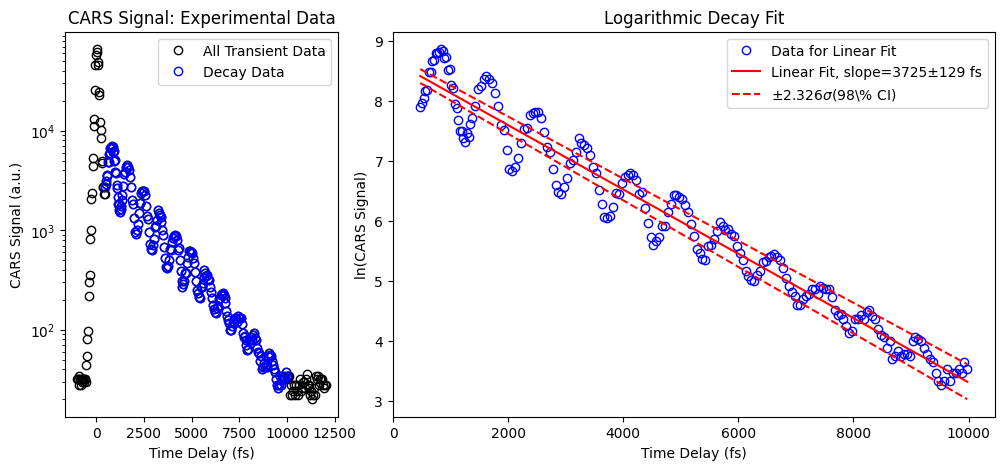

(np.float64(3725.4030921744493), np.float64(129.08403950873856))

In [10]:
tdcars.get_T2(td1=450, td2=10000, show_plot=True)

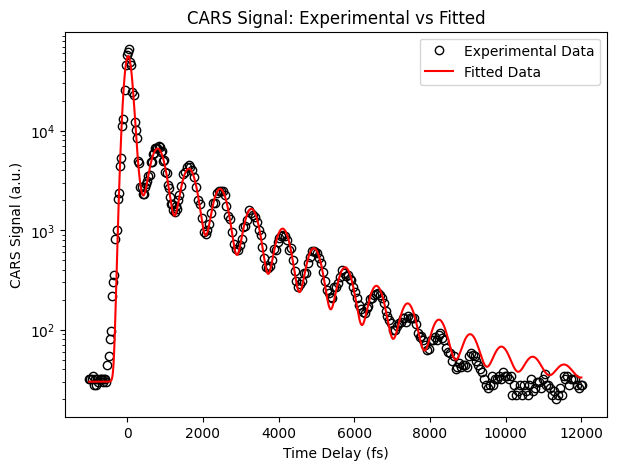

In [11]:
tdcars.tp1, tdcars.tp2, tdcars.tp3 = 100, 200, 200
tdcars.tmin, tdcars.tmax = -2000, 13000
tdcars.floor = 30
nuR = 1200
del_nuR = 20.2
t2 = 3517
del_t2 = -5
tdcars.nuR1 = np.array([nuR, nuR-del_nuR, nuR+del_nuR])
tdcars.T21 = np.array([10, t2-del_t2, t2+del_t2])
tdcars.A1 = np.array([3e24, 2.13E22, 4.44E22]) * 0.4
tdcars.phi=0
td_fit, sig_fit = tdcars.CARS_simulation_FG(showPlot=True)

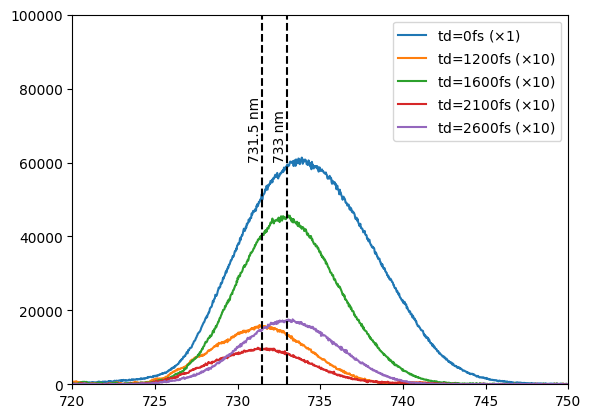

In [12]:
td_arr = np.array([0,1200,1600,2100,2600])
mul = np.array([1,10,10,10,10])
for i, td in enumerate(td_arr):
    _,sig = tdcars.plot_spectra_at_td(td)
    plt.plot(tdcars.wl_as, sig * mul[i], label=f"td={int(td)}fs ($\\times${mul[i]})")
    np.savetxt(f"td_{int(td)}fs.txt", np.column_stack((tdcars.wl_as, sig)), delimiter='\t')
plt.legend()
plt.vlines(731.5, ymin=0, ymax=1e5, colors='k', linestyles='dashed')
plt.text(731.5, 6e4, '731.5 nm', rotation=90, verticalalignment='bottom', horizontalalignment='right')

plt.vlines(733, ymin=0, ymax=1e5, colors='k', linestyles='dashed')
plt.text(733, 6e4, '733 nm', rotation=90, verticalalignment='bottom', horizontalalignment='right')


plt.xlim([720, 750])
plt.ylim([0, 1e5])
plt.show()

In [13]:
1e7 * (1/731.5 - 1/tdcars.wl3)

1324.8609739837823

In [14]:
1e7 * (1/733 - 1/tdcars.wl3)

1296.8857898371316

In [15]:
tdcars.notes_df

,0,1
0,DET,Syncerity CCD
1,SMP,PETN
2,P3 (TiS),150
3,P1 (OPO1),275
4,P2 (OPO2),240
5,Polarizations,All parallel
6,Ti-Sa,810
7,OPO1,1015
8,OPO2,1160
9,MONO,738
